# Giai đoạn 1 — Lựa chọn đặc trưng FAMS

**Mục tiêu:** Áp dụng khung FAMS (5-method ensemble voting) trên bộ dữ liệu Kaggle DDoS
để xác định tập đặc trưng gọn, có tính đại diện cao, phục vụ Giai đoạn 2.

**Bộ dữ liệu:** `final_dataset.csv` — kết hợp CIC-IDS 2017 + CIC-IDS 2018 + CIC-DoS 2016
(12,8M dòng, cân bằng 50/50 DDoS vs Benign)

**Output:** `fams_features.json` — danh sách 18 đặc trưng được chọn → đầu vào của Phase 2

---

**Thiết kế thực nghiệm:**
- RobustScaler thay MinMaxScaler: bền vững với outlier cực trị trong network traffic
- SMOTE bỏ qua: dataset đã cân bằng 50/50
- Test set chỉ dùng ở bước đánh giá cuối (⑨) — không tham gia lựa chọn đặc trưng
- Hai ngưỡng bỏ phiếu (≥3 và >3) được đánh giá; ngưỡng tốt hơn theo F2 được chọn

In [ ]:
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, confusion_matrix,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
print('Imports OK.')

In [ ]:
# ── Cấu hình ──────────────────────────────────────────────────────────────────

KAGGLE_DDOS_FILE = 'data/ddos_balanced/final_dataset.csv'

SEED             = 42
SAMPLE_ROWS      = 1_000_000   # None = đọc toàn bộ 12.8M dòng
TOP_N_PER_METHOD = 25          # Top-K đặc trưng mỗi phương pháp FAMS
VOTE_THRESHOLD_A = 2           # votes >= 3  (ít nhất 3/5 đồng ý)
VOTE_THRESHOLD_B = 3           # votes >  3  (ít nhất 4/5 đồng ý)
CV_FOLDS         = 3           # 3-fold CV cho đánh giá Phase 1

# Subsample cho các phương pháp tốn kém tính toán
SUBSAMPLE_WRAPPER  = 50_000    # RFE (Backward Elimination)
SUBSAMPLE_EMBEDDED = 80_000    # Lasso L1, RF Importance

# ── Cột nhãn và metadata ──────────────────────────────────────────────────────

POSSIBLE_LABEL_COLS = ['Label', 'label', 'Class', 'class', 'target']

# Cột không tham gia feature selection
DROP_COLS = ['Unnamed: 0', 'Timestamp', 'Flow ID', 'Src IP', 'Dst IP',
             'Src Port', 'Dst Port', 'Source IP', 'Destination IP',
             'Source Port', 'Destination Port', 'FlowID']

# Đổi tên cột viết tắt (CIC-IDS style) → tên đầy đủ
RENAME_MAP = {
    'Tot Fwd Pkts':     'Total Fwd Packets',
    'Tot Bwd Pkts':     'Total Backward Packets',
    'TotLen Fwd Pkts':  'Fwd Packets Length Total',
    'TotLen Bwd Pkts':  'Bwd Packets Length Total',
    'Fwd Pkt Len Max':  'Fwd Packet Length Max',
    'Fwd Pkt Len Min':  'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std':  'Fwd Packet Length Std',
    'Bwd Pkt Len Max':  'Bwd Packet Length Max',
    'Bwd Pkt Len Min':  'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std':  'Bwd Packet Length Std',
    'Flow Byts/s':      'Flow Bytes/s',
    'Flow Pkts/s':      'Flow Packets/s',
    'Fwd IAT Tot':      'Fwd IAT Total',
    'Bwd IAT Tot':      'Bwd IAT Total',
    'Fwd Header Len':   'Fwd Header Length',
    'Bwd Header Len':   'Bwd Header Length',
    'Fwd Pkts/s':       'Fwd Packets/s',
    'Bwd Pkts/s':       'Bwd Packets/s',
    'Pkt Len Min':      'Packet Length Min',
    'Pkt Len Max':      'Packet Length Max',
    'Pkt Len Mean':     'Packet Length Mean',
    'Pkt Len Std':      'Packet Length Std',
    'Pkt Len Var':      'Packet Length Variance',
    'FIN Flag Cnt':     'FIN Flag Count',
    'SYN Flag Cnt':     'SYN Flag Count',
    'RST Flag Cnt':     'RST Flag Count',
    'PSH Flag Cnt':     'PSH Flag Count',
    'ACK Flag Cnt':     'ACK Flag Count',
    'URG Flag Cnt':     'URG Flag Count',
    'ECE Flag Cnt':     'ECE Flag Count',
    'Pkt Size Avg':     'Avg Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',
    'Init Fwd Win Byts':'Init Fwd Win Bytes',
    'Init Bwd Win Byts':'Init Bwd Win Bytes',
    'Fwd Act Data Pkts':'Fwd Act Data Packets',
}

print('Cấu hình OK.')

## 1. Nạp và Chuẩn hoá Dữ liệu

Đọc `final_dataset.csv` — 12,8M dòng, cân bằng 50/50 (DDoS vs Benign).
Do kích thước file lớn, lấy mẫu ngẫu nhiên `SAMPLE_ROWS = 1_000_000` dòng bằng cách
bỏ qua chỉ số ngẫu nhiên khi đọc CSV, đảm bảo tính đại diện mà không cần nạp toàn bộ
file vào bộ nhớ.

Sau khi nạp:
- Chuẩn hoá tên cột (strip khoảng trắng, đổi tên viết tắt CIC-IDS → tên đầy đủ)
- Tìm cột nhãn tự động từ danh sách `POSSIBLE_LABEL_COLS`
- Bỏ các cột metadata không mang thông tin phân loại (IP, Port, Timestamp, FlowID)

In [3]:
if not os.path.exists(KAGGLE_DDOS_FILE):
    raise FileNotFoundError(
        f'Không tìm thấy {KAGGLE_DDOS_FILE}\n'
        'Tải từ: https://www.kaggle.com/datasets/devendra416/ddos-datasets\n'
        'Đặt file vào: data/ddos_balanced/final_dataset.csv'
    )

print(f'Đang nạp {KAGGLE_DDOS_FILE} ...')
t0 = time.time()

if SAMPLE_ROWS:
    # Đọc header trước để biết tổng số dòng, sau đó random sample
    total_rows = sum(1 for _ in open(KAGGLE_DDOS_FILE)) - 1  # trừ header
    print(f'  Tổng dòng trong file: {total_rows:,}')
    skip_idx = sorted(np.random.RandomState(SEED).choice(
        total_rows, total_rows - SAMPLE_ROWS, replace=False
    ) + 1)  # +1 vì dòng 0 là header
    df_raw = pd.read_csv(KAGGLE_DDOS_FILE, skiprows=skip_idx, low_memory=False)
    print(f'  Sample {SAMPLE_ROWS:,} dòng ngẫu nhiên.')
else:
    df_raw = pd.read_csv(KAGGLE_DDOS_FILE, low_memory=False)

print(f'Nạp xong trong {time.time()-t0:.1f}s | {len(df_raw):,} dòng | {df_raw.shape[1]} cột')

# Chuẩn hoá tên cột
df_raw.columns = df_raw.columns.str.strip()
df_raw.rename(columns=RENAME_MAP, inplace=True)

# Tìm cột nhãn
label_col = None
for c in POSSIBLE_LABEL_COLS:
    if c in df_raw.columns:
        label_col = c
        break
if label_col is None:
    raise ValueError(f'Không tìm thấy cột nhãn. Các cột: {df_raw.columns.tolist()}')
print(f'Cột nhãn: "{label_col}"')

# Chuẩn hoá nhãn
df_raw[label_col] = df_raw[label_col].astype(str).str.strip()
print('Phân phối nhãn gốc:')
print(df_raw[label_col].value_counts())

if label_col != 'Label':
    df_raw.rename(columns={label_col: 'Label'}, inplace=True)

# Bỏ cột metadata
cols_to_drop = [c for c in DROP_COLS if c in df_raw.columns]
if cols_to_drop:
    df_raw.drop(columns=cols_to_drop, inplace=True)
    print(f'Đã bỏ cột metadata: {cols_to_drop}')

print(f'\nSau xử lý: {len(df_raw):,} dòng | {df_raw.shape[1]} cột')

Đang nạp data/ddos_balanced/final_dataset.csv ...


  Tổng dòng trong file: 12,794,627


  Sample 1,000,000 dòng ngẫu nhiên.
Nạp xong trong 36.3s | 1,000,000 dòng | 85 cột
Cột nhãn: "Label"
Phân phối nhãn gốc:
Label
ddos      506638
Benign    493362
Name: count, dtype: int64


Đã bỏ cột metadata: ['Unnamed: 0', 'Timestamp', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port']

Sau xử lý: 1,000,000 dòng | 78 cột


## 2. Tiền xử lý

Xử lý các vấn đề chất lượng dữ liệu thường gặp trong bộ dữ liệu lưu lượng mạng CIC:
- Ép kiểu cột `object` → số (một số cột bị đọc sai kiểu do ký tự đặc biệt)
- Thay thế `±∞` bằng `NaN` (xuất hiện khi chia cho 0 trong tính toán flow features)
- `dropna()` để loại dòng không đầy đủ
- `drop_duplicates()` để loại các dòng trùng lặp (flow được ghi nhiều lần)

In [4]:
df = df_raw.copy()

# Ép kiểu object → số
for col in df.columns:
    if col != 'Label' and df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ±∞ → NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Trước dropna:  {len(df):,} dòng')

df.dropna(inplace=True)
print(f'Sau dropna:    {len(df):,} dòng')

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Sau dedup:     {len(df):,} dòng  (xoá {before - len(df):,} dòng trùng)')

feature_cols = [
    c for c in df.columns
    if c != 'Label' and pd.api.types.is_numeric_dtype(df[c])
]
print(f'Đặc trưng số ứng viên: {len(feature_cols)}')

Trước dropna:  1,000,000 dòng
Sau dropna:    996,238 dòng


Sau dedup:     765,712 dòng  (xoá 230,526 dòng trùng)
Đặc trưng số ứng viên: 77


## 3. Mã hoá Nhãn Nhị phân

Chuyển nhãn dạng chuỗi (`"Benign"`, `"ddos"`) sang nhị phân:
- `0` = lưu lượng bình thường (BENIGN)
- `1` = lưu lượng tấn công (DDoS)

So sánh không phân biệt chữ hoa/thường để xử lý các biến thể tên nhãn trong dataset.

In [5]:
df['label_bin'] = (df['Label'].str.upper() != 'BENIGN').astype(int)

X = df[feature_cols].values.astype(np.float32)
y = df['label_bin'].values
feat_names = np.array(feature_cols)

cnt = Counter(y)
print(f'BENIGN (0): {cnt[0]:,}  ({cnt[0]/len(y)*100:.1f}%)')
print(f'ATTACK (1): {cnt[1]:,}  ({cnt[1]/len(y)*100:.1f}%)')
print(f'Ratio: {max(cnt.values())/min(cnt.values()):.1f}:1')

BENIGN (0): 399,701  (52.2%)
ATTACK (1): 366,011  (47.8%)
Ratio: 1.1:1


## 4. Phân chia Train / Test — Stratified 70/30

Phân chia stratified đảm bảo tỷ lệ lớp trong train và test nhất quán với tập gốc.
**Test set được giữ hoàn toàn tách biệt** — chỉ dùng ở bước đánh giá cuối (mục 7),
không tham gia bất kỳ bước lựa chọn đặc trưng nào để tránh data leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train class: {Counter(y_train)}')
print(f'Test  class: {Counter(y_test)}')

Train: 535,998 | Test: 229,714
Train class: Counter({np.int64(0): 279790, np.int64(1): 256208})
Test  class: Counter({np.int64(0): 119911, np.int64(1): 109803})


## 5. Chuẩn hoá Đặc trưng — RobustScaler

**RobustScaler** dùng median và IQR thay vì mean/std hoặc min/max, bền vững hơn với
các giá trị ngoại lệ cực trị thường gặp trong lưu lượng mạng (burst traffic, flood attack
tạo ra khoảng cách rất lớn giữa phân vị 75% và giá trị max).

Quy trình: `fit` trên `X_train` → `transform` cả `X_train` và `X_test`.
Không `fit` trên test set để tránh rò rỉ thông tin phân phối tập test vào quá trình lựa chọn đặc trưng.

In [7]:
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_sc, columns=feat_names)
X_test_df  = pd.DataFrame(X_test_sc,  columns=feat_names)
print('RobustScaler fit trên train, transform cả hai tập. OK.')

RobustScaler fit trên train, transform cả hai tập. OK.


## 6. Cân bằng Lớp — SMOTE bỏ qua

Dataset `final_dataset.csv` được tạo ra với mục tiêu cân bằng lớp (50/50 DDoS vs Benign),
nên SMOTE không cần thiết. Sau khi `dropna` và `drop_duplicates`, tỷ lệ thực tế vẫn gần
bằng nhau (~52/48), không ảnh hưởng đáng kể đến quá trình lựa chọn đặc trưng.

In [8]:
cnt_tr = Counter(y_train)
ratio  = max(cnt_tr.values()) / min(cnt_tr.values())
print(f'Tỷ lệ lớp (train): {ratio:.2f}:1')
print('Dataset đã balanced → bỏ qua SMOTE.')

# Dùng trực tiếp — không oversample
y_train_fs = y_train
print(f'X_train_df shape: {X_train_df.shape} | y_train_fs: {Counter(y_train_fs)}')

Tỷ lệ lớp (train): 1.09:1
Dataset đã balanced → bỏ qua SMOTE.
X_train_df shape: (535998, 77) | y_train_fs: Counter({np.int64(0): 279790, np.int64(1): 256208})


## 7. Lựa chọn Đặc trưng — 5 phương pháp FAMS

Khung FAMS (Ma et al., 2023) kết hợp 5 phương pháp từ 3 nhóm khác nhau để đảm bảo
tính đa dạng quan điểm:

| # | Nhóm | Phương pháp | Cơ sở lý thuyết |
|---|------|-------------|-----------------|
| 1 | Filter | Variance | Loại đặc trưng phương sai thấp (ít thông tin phân biệt) |
| 2 | Filter | Mutual Information | Đo lường phụ thuộc thống kê phi tuyến với nhãn |
| 3 | Wrapper | Backward Elimination (RFE) | Đánh giá kết hợp đặc trưng theo hiệu suất mô hình |
| 4 | Embedded | Lasso L1 | Hệ số Logistic Regression với regularization L1 |
| 5 | Embedded | RF Importance | Feature importance từ Random Forest (Gini impurity) |

Mỗi phương pháp chọn **top-25 đặc trưng**. Phương pháp Wrapper và Embedded dùng
subsample stratified (`SUBSAMPLE_WRAPPER`, `SUBSAMPLE_EMBEDDED`) để kiểm soát
thời gian tính toán mà vẫn đảm bảo tính đại diện của mẫu.

In [9]:
# ── Phương pháp 1: Filter — Variance ─────────────────────────────────────────
print('Phương pháp 1: Variance Filter ...')

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_df)
nonzero_feats = feat_names[vt.get_support()]

variances = X_train_df[nonzero_feats].var().sort_values(ascending=False)
selected_variance = variances.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Đặc trưng phương sai ≠ 0: {len(nonzero_feats)}')
print(f'  Top-{TOP_N_PER_METHOD}: {selected_variance[:5]} ...')

Phương pháp 1: Variance Filter ...


  Đặc trưng phương sai ≠ 0: 69
  Top-25: ['Idle Max', 'Idle Mean', 'Idle Min', 'Active Max', 'Active Mean'] ...


Phương pháp 2: Mutual Information ...


  Top-25: ['Init Bwd Win Bytes', 'Packet Length Max', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Packet Length Std'] ...


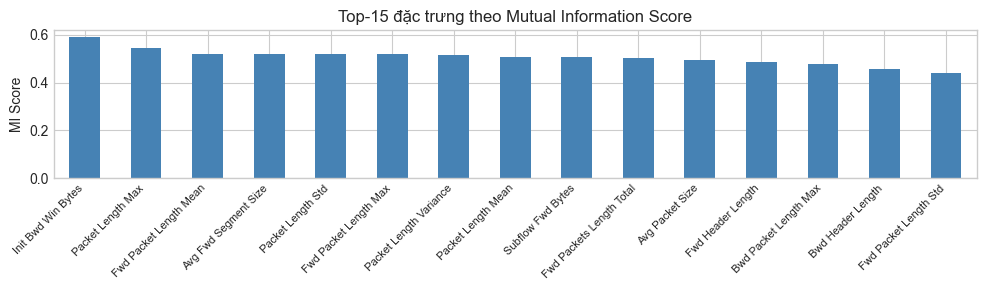

In [10]:
# ── Phương pháp 2: Filter — Mutual Information ────────────────────────────────
print('Phương pháp 2: Mutual Information ...')

mi_scores = mutual_info_classif(
    X_train_df, y_train_fs, discrete_features=False, random_state=SEED
)
mi_series = pd.Series(mi_scores, index=feat_names).sort_values(ascending=False)
selected_mi = mi_series.head(TOP_N_PER_METHOD).index.tolist()

print(f'  Top-{TOP_N_PER_METHOD}: {selected_mi[:5]} ...')

fig, ax = plt.subplots(figsize=(10, 3))
mi_series.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top-15 đặc trưng theo Mutual Information Score')
ax.set_ylabel('MI Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase1_mi_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Phương pháp 3: Wrapper — Backward Elimination (RFE) ──────────────────────
# Subsample stratified để tiết kiệm thời gian
print('Phương pháp 3: Backward Elimination (RFE) — có thể mất vài phút ...')

if len(X_train_df) > SUBSAMPLE_WRAPPER:
    idx = np.random.RandomState(SEED).choice(len(X_train_df), SUBSAMPLE_WRAPPER, replace=False)
    X_rfe, y_rfe = X_train_df.iloc[idx], y_train_fs[idx]
    print(f'  Subsample: {SUBSAMPLE_WRAPPER:,} dòng (stratified)')
else:
    X_rfe, y_rfe = X_train_df, y_train_fs

rfe = RFE(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=SEED),
    n_features_to_select=TOP_N_PER_METHOD, step=3
)
t0 = time.time()
rfe.fit(X_rfe, y_rfe)
selected_rfe = feat_names[rfe.support_].tolist()
print(f'  Hoàn thành trong {time.time()-t0:.1f}s')
print(f'  Top-{TOP_N_PER_METHOD}: {selected_rfe[:5]} ...')

Phương pháp 3: Backward Elimination (RFE) — có thể mất vài phút ...
  Subsample: 50,000 dòng (stratified)


  Hoàn thành trong 4.7s
  Top-25: ['Flow Duration', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min'] ...


In [12]:
# ── Phương pháp 4: Embedded — Lasso L1 ───────────────────────────────────────
print('Phương pháp 4: Lasso L1 (Logistic Regression) ...')

if len(X_train_df) > SUBSAMPLE_EMBEDDED:
    idx = np.random.RandomState(SEED).choice(len(X_train_df), SUBSAMPLE_EMBEDDED, replace=False)
    X_lasso, y_lasso = X_train_df.iloc[idx], y_train_fs[idx]
    print(f'  Subsample: {SUBSAMPLE_EMBEDDED:,} dòng')
else:
    X_lasso, y_lasso = X_train_df, y_train_fs

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=500, random_state=SEED)
t0 = time.time()
lasso.fit(X_lasso, y_lasso)
print(f'  Hoàn thành trong {time.time()-t0:.1f}s')

coef_series = pd.Series(np.abs(lasso.coef_[0]), index=feat_names).sort_values(ascending=False)
selected_lasso = coef_series[coef_series > 0].head(TOP_N_PER_METHOD).index.tolist()
print(f'  Đặc trưng coef ≠ 0: {(coef_series > 0).sum()}')
print(f'  Top-{TOP_N_PER_METHOD}: {selected_lasso[:5]} ...')

Phương pháp 4: Lasso L1 (Logistic Regression) ...
  Subsample: 80,000 dòng


  Hoàn thành trong 179.5s
  Đặc trưng coef ≠ 0: 69
  Top-25: ['Bwd PSH Flags', 'CWE Flag Count', 'Fwd PSH Flags', 'Packet Length Std', 'ACK Flag Count'] ...


In [13]:
# ── Phương pháp 5: Embedded — RF Importance ───────────────────────────────────
print('Phương pháp 5: RF Importance ...')

if len(X_train_df) > SUBSAMPLE_EMBEDDED:
    idx = np.random.RandomState(SEED).choice(len(X_train_df), SUBSAMPLE_EMBEDDED, replace=False)
    X_rffs, y_rffs = X_train_df.iloc[idx], y_train_fs[idx]
    print(f'  Subsample: {SUBSAMPLE_EMBEDDED:,} dòng')
else:
    X_rffs, y_rffs = X_train_df, y_train_fs

rf_fs = RandomForestClassifier(
    n_estimators=50, max_depth=10, max_samples=0.8,
    n_jobs=-1, random_state=SEED
)
t0 = time.time()
rf_fs.fit(X_rffs, y_rffs)
print(f'  Hoàn thành trong {time.time()-t0:.1f}s')

imp_series = pd.Series(rf_fs.feature_importances_, index=feat_names).sort_values(ascending=False)
selected_rf_fs = imp_series.head(TOP_N_PER_METHOD).index.tolist()
print(f'  Top-{TOP_N_PER_METHOD}: {selected_rf_fs[:5]} ...')

Phương pháp 5: RF Importance ...
  Subsample: 80,000 dòng


  Hoàn thành trong 0.4s
  Top-25: ['Fwd Seg Size Min', 'Avg Fwd Segment Size', 'Init Bwd Win Bytes', 'Fwd Packet Length Std', 'Fwd Packet Length Max'] ...


## 8. Bỏ phiếu FAMS — Tổng hợp kết quả

Mỗi phương pháp bỏ 1 phiếu cho mỗi đặc trưng trong top-25 của nó (max = 5 phiếu).
Đặc trưng được nhiều phương pháp đồng thuận → có tính ổn định cao hơn và ít phụ
thuộc vào giả định của một phương pháp đơn lẻ.

Hai ngưỡng được đánh giá song song:
- **votes ≥ 3**: ít nhất 3/5 phương pháp đồng ý → tập rộng hơn, bao phủ nhiều hơn
- **votes > 3**: ít nhất 4/5 phương pháp đồng ý → tập chặt hơn, ổn định hơn

Ngưỡng cuối cùng được chọn dựa trên F2-score trung bình ở bước đánh giá (mục 9).

Ngưỡng votes ≥ 3: 18 đặc trưng
Ngưỡng votes > 3: 6 đặc trưng

--- votes >= 3 ---
                 Feature  Votes                                                           Methods
  Fwd Packet Length Mean      4 Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
   Fwd Packet Length Max      4 Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
Fwd Packets Length Total      4 Variance, Mutual Information, Backward Elim. (RFE), RF Importance
        Fwd Seg Size Min      4 Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
            Flow IAT Min      4 Variance, Mutual Information, Backward Elim. (RFE), RF Importance
   Fwd Packet Length Std      4 Mutual Information, Backward Elim. (RFE), Lasso L1, RF Importance
       Subflow Bwd Bytes      3                Variance, Mutual Information, Backward Elim. (RFE)
       Packet Length Max      3                       Mutual Information, Lasso L1, RF Importance
      Init Bwd Win Bytes      3      

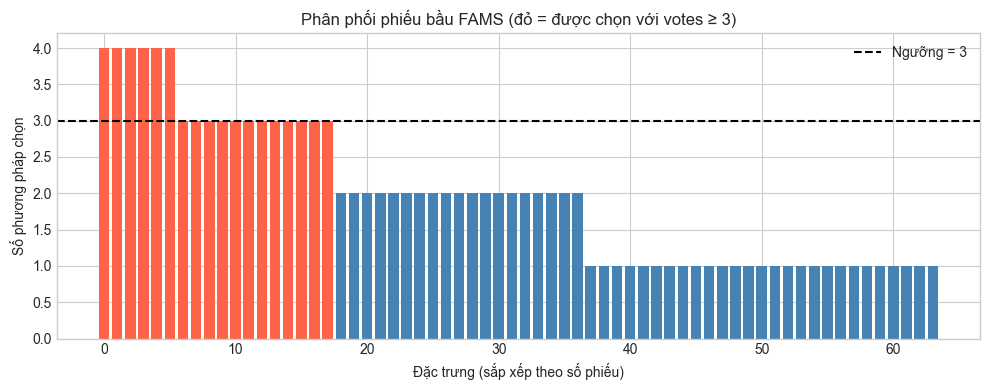

In [14]:
all_methods = [
    ('Variance',             selected_variance),
    ('Mutual Information',   selected_mi),
    ('Backward Elim. (RFE)', selected_rfe),
    ('Lasso L1',             selected_lasso),
    ('RF Importance',        selected_rf_fs),
]

vote_counter = Counter()
for _, feats in all_methods:
    vote_counter.update(feats)

vote_df = pd.DataFrame(
    [(f, v) for f, v in vote_counter.items()],
    columns=['Feature', 'Votes']
).sort_values('Votes', ascending=False)

method_map = {m: set(f) for m, f in all_methods}
vote_df['Methods'] = vote_df['Feature'].apply(
    lambda f: ', '.join([m for m, s in method_map.items() if f in s])
)

# Hai ngưỡng
fams_A = vote_df[vote_df['Votes'] >= 3]['Feature'].tolist()  # votes >= 3
fams_B = vote_df[vote_df['Votes'] >  3]['Feature'].tolist()  # votes >  3

print(f'Ngưỡng votes ≥ 3: {len(fams_A)} đặc trưng')
print(f'Ngưỡng votes > 3: {len(fams_B)} đặc trưng')
print('\n--- votes >= 3 ---')
print(vote_df[vote_df['Votes'] >= 3][['Feature','Votes','Methods']].to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['tomato' if v >= 3 else 'steelblue' for v in vote_df['Votes']]
ax.bar(range(len(vote_df)), vote_df['Votes'], color=bar_colors)
ax.axhline(y=3, color='black', linestyle='--', lw=1.5, label='Ngưỡng = 3')
ax.set_xlabel('Đặc trưng (sắp xếp theo số phiếu)')
ax.set_ylabel('Số phương pháp chọn')
ax.set_title('Phân phối phiếu bầu FAMS (đỏ = được chọn với votes ≥ 3)')
ax.legend()
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase1_fams_votes.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Đánh giá Tập Đặc trưng — Chọn Ngưỡng

Đây là lần đầu tiên test set được sử dụng. Ba mô hình (KNN, RF, XGB) với siêu tham số
mặc định được huấn luyện trên train set và đánh giá trên test set cho cả hai ngưỡng.

**Metrics:**
- **F2-score** (β=2): ưu tiên Recall hơn Precision — phù hợp với bài toán phát hiện tấn công
  nơi bỏ sót tấn công (FN) nguy hiểm hơn báo động nhầm (FP)
- **FNR** (False Negative Rate): tỷ lệ tấn công bị bỏ sót
- **AUC**: đánh giá khả năng phân biệt tổng thể độc lập với ngưỡng quyết định
- **CV F1**: F1 trung bình 3-fold CV trên train set — kiểm tra tính ổn định

Ngưỡng có F2 trung bình cao hơn được chọn làm tập đặc trưng FAMS cuối cùng cho Phase 2.

In [15]:
def evaluate_phase1(feature_list, label, X_tr_df, y_tr, X_te_df, y_te):
    """Đánh giá tập đặc trưng với KNN, RF, XGB — 3-fold CV + test set."""
    avail = [f for f in feature_list if f in X_tr_df.columns]
    print(f'\n=== {label} ({len(avail)} đặc trưng) ===')

    X_tr = X_tr_df[avail].values
    X_te = X_te_df[avail].values

    models = {
        'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'RF':  RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced'),
        'XGB': XGBClassifier(n_estimators=100, random_state=SEED, n_jobs=-1,
                              eval_metric='logloss', verbosity=0),
    }
    # Lưu ý: KNN không hỗ trợ class_weight — chạy không có cân bằng lớp

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    rows = []
    for mname, model in models.items():
        cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1)
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        rows.append({
            'Model':    mname,
            'CV_F1':    f'{cv_f1.mean():.4f}±{cv_f1.std():.4f}',
            'Accuracy': round(accuracy_score(y_te, y_pred), 4),
            'Precision':round(precision_score(y_te, y_pred, zero_division=0), 4),
            'Recall':   round(recall_score(y_te, y_pred, zero_division=0), 4),
            'F1':       round(f1_score(y_te, y_pred, zero_division=0), 4),
            'F2':       round(fbeta_score(y_te, y_pred, beta=2, zero_division=0), 4),
            'FNR':      round(fnr, 4),
            'AUC':      round(roc_auc_score(y_te, y_proba), 4),
        })
    result_df = pd.DataFrame(rows)
    print(result_df.to_string(index=False))
    return result_df

results_A = evaluate_phase1(fams_A, 'votes >= 3', X_train_df, y_train_fs, X_test_df, y_test)
results_B = evaluate_phase1(fams_B, 'votes >  3', X_train_df, y_train_fs, X_test_df, y_test)


=== votes >= 3 (18 đặc trưng) ===


Model         CV_F1  Accuracy  Precision  Recall     F1     F2    FNR    AUC
  KNN 0.9927±0.0000    0.9930     0.9916  0.9939 0.9927 0.9934 0.0061 0.9975
   RF 0.9971±0.0000    0.9972     0.9976  0.9966 0.9971 0.9968 0.0034 0.9995
  XGB 0.9971±0.0001    0.9972     0.9980  0.9961 0.9971 0.9965 0.0039 1.0000

=== votes >  3 (6 đặc trưng) ===


Model         CV_F1  Accuracy  Precision  Recall     F1     F2    FNR    AUC
  KNN 0.9824±0.0002    0.9828     0.9777  0.9866 0.9821 0.9848 0.0134 0.9939
   RF 0.9809±0.0003    0.9818     0.9808  0.9812 0.9810 0.9811 0.0188 0.9955
  XGB 0.9827±0.0003    0.9832     0.9769  0.9883 0.9826 0.9860 0.0117 0.9986


In [16]:
# ── Chọn ngưỡng và lưu FAMS features ─────────────────────────────────────────
# Chọn ngưỡng dựa trên F2 trung bình trên test set

mean_f2_A = results_A['F2'].mean()
mean_f2_B = results_B['F2'].mean()

print(f'F2 trung bình — votes >= 3: {mean_f2_A:.4f} ({len(fams_A)} đặc trưng)')
print(f'F2 trung bình — votes >  3: {mean_f2_B:.4f} ({len(fams_B)} đặc trưng)')

if mean_f2_A >= mean_f2_B:
    FAMS_FEATURES = fams_A
    print(f'\n→ Chọn ngưỡng votes >= 3: {len(FAMS_FEATURES)} đặc trưng')
else:
    FAMS_FEATURES = fams_B
    print(f'\n→ Chọn ngưỡng votes >  3: {len(FAMS_FEATURES)} đặc trưng')

print('\nFAMS Features cuối cùng:')
for i, f in enumerate(FAMS_FEATURES, 1):
    print(f'  {i:2d}. {f}')

# Lưu danh sách đặc trưng để Phase 2 nạp
import json
with open('fams_features.json', 'w') as fp:
    json.dump(FAMS_FEATURES, fp, indent=2)
print('\nĐã lưu vào fams_features.json → dùng cho Phase 2.')

F2 trung bình — votes >= 3: 0.9956 (18 đặc trưng)
F2 trung bình — votes >  3: 0.9840 (6 đặc trưng)

→ Chọn ngưỡng votes >= 3: 18 đặc trưng

FAMS Features cuối cùng:
   1. Fwd Packet Length Mean
   2. Fwd Packet Length Max
   3. Fwd Packets Length Total
   4. Fwd Seg Size Min
   5. Flow IAT Min
   6. Fwd Packet Length Std
   7. Subflow Bwd Bytes
   8. Packet Length Max
   9. Init Bwd Win Bytes
  10. Packet Length Std
  11. Subflow Fwd Bytes
  12. Fwd Header Length
  13. Flow Packets/s
  14. Bwd Packet Length Max
  15. Bwd Packets Length Total
  16. Avg Fwd Segment Size
  17. Subflow Fwd Packets
  18. Bwd Packet Length Std

Đã lưu vào fams_features.json → dùng cho Phase 2.


## 10. Nhận xét và Giới hạn

### Kết quả chính

Tập 18 đặc trưng (ngưỡng votes ≥ 3) đạt F2 ≥ 0,99 trên cả ba mô hình — cho thấy
khung FAMS hoạt động tốt trên bộ dữ liệu này. Sự đồng thuận giữa 5 phương pháp
từ 3 nhóm khác nhau (filter, wrapper, embedded) củng cố tính ổn định của tập đặc trưng.

Tập 6 đặc trưng (ngưỡng votes > 3) có hiệu suất thấp hơn rõ rệt (F2 ≈ 0,98),
cho thấy ngưỡng quá chặt loại bỏ nhiều đặc trưng có giá trị phân biệt thực sự.

### Giới hạn

- **Phụ thuộc bộ dữ liệu nguồn:** Tập đặc trưng FAMS được chọn từ CIC-IDS 2017/2018/DoS 2016
  — các bộ dữ liệu này sinh ra từ cùng một công cụ trích xuất (CICFlowMeter) và có thể
  không bao phủ đầy đủ đặc trưng lưu lượng từ các môi trường mạng khác nhau.

- **Subsample cho Wrapper/Embedded:** RFE (50k dòng) và Lasso/RF (80k dòng) chỉ nhìn thấy
  một phần nhỏ của 536k dòng train, có thể bỏ sót các đặc trưng chỉ quan trọng trong
  các tình huống lưu lượng cụ thể.

- **Tổng quát hóa sang CIC-DDoS 2019:** Hiệu quả thực sự của tập đặc trưng này trên
  dữ liệu hoàn toàn mới (các nhóm tấn công NTP/TFTP, SYN, WebDDoS) được đánh giá
  trong Giai đoạn 2 thông qua thiết kế Leave-One-Group-Out.